In [22]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

In [23]:


df = pd.read_csv("../data/fake_job_postings.csv")

print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df["fraudulent"].value_counts())

(17880, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  obje

In [24]:
# Check missing values as percentages

missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": df.isnull().mean() * 100
})

missing = missing[missing["Missing Count"] > 0]
missing.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
salary_range,15012,83.959732
department,11547,64.580537
required_education,8105,45.329978
benefits,7212,40.335570
required_experience,7050,39.429530
function,6455,36.101790
industry,4903,27.421700
employment_type,3471,19.412752
company_profile,3308,18.501119
requirements,2696,15.078300


In [25]:
# Check duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [26]:
# Check unique values in categorical columns

categorical_columns = [
    "location",
    "department",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

for col in categorical_columns:
    print("\n====================")
    print(col)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(10))


location
Unique values: 3105
location
GB, LND, London          718
US, NY, New York         658
US, CA, San Francisco    472
GR, I, Athens            464
NaN                      346
US, ,                    339
US, TX, Houston          269
US, IL, Chicago          255
US, DC, Washington       251
DE, BE, Berlin           221
Name: count, dtype: int64

department
Unique values: 1337
department
NaN                       11547
Sales                       551
Engineering                 487
Marketing                   401
Operations                  270
IT                          225
Development                 146
Product                     112
Information Technology       86
Design                       76
Name: count, dtype: int64

employment_type
Unique values: 5
employment_type
Full-time    11620
NaN           3471
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

required_experience
Unique values: 7
required_experience
NaN     

In [27]:
for col in [
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]:
    print("\n==============================")
    print(col)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(15))


employment_type
Unique values: 5
employment_type
Full-time    11620
NaN           3471
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

required_experience
Unique values: 7
required_experience
NaN                 7050
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

required_education
Unique values: 13
required_education
NaN                                  8105
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Some High School Coursework            27
Doctora

In [28]:
for col in ["required_education", "industry", "function"]:
    print("\n==============================")
    print(col)
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(15))


required_education
Unique values: 13
required_education
NaN                                  8105
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Some High School Coursework            27
Doctorate                              26
Vocational - HS Diploma                 9
Vocational - Degree                     6
Name: count, dtype: int64

industry
Unique values: 131
industry
NaN                                    4903
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
Financial Services         

In [29]:
print(df["industry"].value_counts(dropna=False).head(20))

industry
NaN                                    4903
Information Technology and Services    1734
Computer Software                      1376
Internet                               1062
Marketing and Advertising               828
Education Management                    822
Financial Services                      779
Hospital & Health Care                  497
Consumer Services                       358
Telecommunications                      342
Oil & Energy                            287
Retail                                  223
Real Estate                             175
Accounting                              159
Construction                            158
E-Learning                              139
Management Consulting                   130
Design                                  129
Health, Wellness and Fitness            127
Staffing and Recruiting                 127
Name: count, dtype: int64


In [30]:
print(df["function"].value_counts(dropna=False).head(20))

function
NaN                       6455
Information Technology    1749
Sales                     1468
Engineering               1348
Customer Service          1229
Marketing                  830
Administrative             630
Design                     340
Health Care Provider       338
Other                      325
Education                  325
Management                 317
Business Development       228
Accounting/Auditing        212
Human Resources            205
Project Management         183
Finance                    172
Consulting                 144
Writing/Editing            132
Art/Creative               132
Name: count, dtype: int64


In [31]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [32]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().mean() * 100).round(2)
})

missing.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
salary_range,15012,83.96
department,11547,64.58
required_education,8105,45.33
benefits,7212,40.34
required_experience,7050,39.43
function,6455,36.10
industry,4903,27.42
employment_type,3471,19.41
company_profile,3308,18.50
requirements,2696,15.08


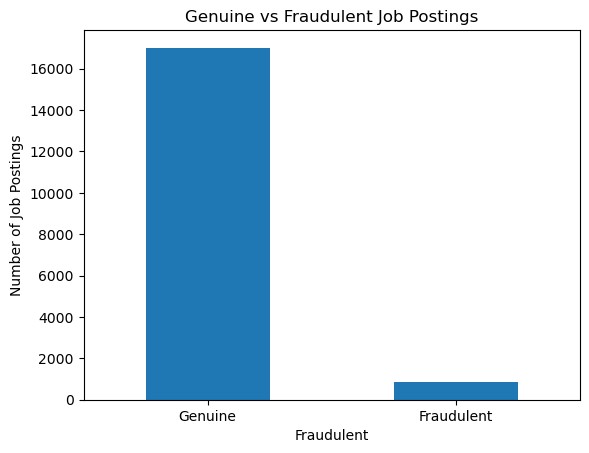

In [33]:
import matplotlib.pyplot as plt

df["fraudulent"].value_counts().plot(
    kind="bar"
)

plt.title("Genuine vs Fraudulent Job Postings")
plt.xlabel("Fraudulent")
plt.ylabel("Number of Job Postings")
plt.xticks(
    [0, 1],
    ["Genuine", "Fraudulent"],
    rotation=0
)

plt.show()

In [34]:
columns_to_check = [
    "salary_range",
    "department",
    "company_profile",
    "requirements",
    "benefits",
    "required_experience",
    "required_education",
    "function",
    "industry",
    "employment_type",
    "location"
]

for col in columns_to_check:
    print("\n==============================")
    print(col)

    missing_fraud_rate = df.loc[df[col].isna(), "fraudulent"].mean() * 100
    present_fraud_rate = df.loc[df[col].notna(), "fraudulent"].mean() * 100

    print(f"Fraud rate when missing : {missing_fraud_rate:.2f}%")
    print(f"Fraud rate when present : {present_fraud_rate:.2f}%")


salary_range
Fraud rate when missing : 4.28%
Fraud rate when present : 7.78%

department
Fraud rate when missing : 4.60%
Fraud rate when present : 5.29%

company_profile
Fraud rate when missing : 17.74%
Fraud rate when present : 1.91%

requirements
Fraud rate when missing : 5.71%
Fraud rate when present : 4.69%

benefits
Fraud rate when missing : 5.05%
Fraud rate when present : 4.71%

required_experience
Fraud rate when missing : 6.17%
Fraud rate when present : 3.98%

required_education
Fraud rate when missing : 5.56%
Fraud rate when present : 4.25%

function
Fraud rate when missing : 5.22%
Fraud rate when present : 4.63%

industry
Fraud rate when missing : 5.61%
Fraud rate when present : 4.55%

employment_type
Fraud rate when missing : 6.94%
Fraud rate when present : 4.34%

location
Fraud rate when missing : 5.49%
Fraud rate when present : 4.83%


In [35]:
for col in [
    "salary_range",
    "department",
    "company_profile",
    "requirements",
    "benefits"
]:
    print("\n==============================")
    print(col)

    missing_fraud_rate = df.loc[df[col].isna(), "fraudulent"].mean() * 100
    present_fraud_rate = df.loc[df[col].notna(), "fraudulent"].mean() * 100

    print(f"Fraud rate when missing : {missing_fraud_rate:.2f}%")
    print(f"Fraud rate when present : {present_fraud_rate:.2f}%")


salary_range
Fraud rate when missing : 4.28%
Fraud rate when present : 7.78%

department
Fraud rate when missing : 4.60%
Fraud rate when present : 5.29%

company_profile
Fraud rate when missing : 17.74%
Fraud rate when present : 1.91%

requirements
Fraud rate when missing : 5.71%
Fraud rate when present : 4.69%

benefits
Fraud rate when missing : 5.05%
Fraud rate when present : 4.71%


In [36]:
# Make a copy so we don't accidentally modify the original dataset
df_clean = df.copy()

# Drop identifier and high-missing/high-cardinality department
df_clean = df_clean.drop(columns=["job_id", "department"])

# Create missing-value indicators
missing_indicator_columns = [
    "company_profile",
    "requirements",
    "benefits",
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function",
    "location",
    "salary_range"
]

for col in missing_indicator_columns:
    df_clean[f"{col}_missing"] = df_clean[col].isna().astype(int)

print(df_clean.shape)

(17880, 26)


In [37]:
text_columns = [
    "title",
    "company_profile",
    "description",
    "requirements",
    "benefits"
]

for col in text_columns:
    df_clean[f"{col}_word_count"] = (
        df_clean[col]
        .fillna("")
        .str.split()
        .str.len()
    )

    df_clean[f"{col}_char_count"] = (
        df_clean[col]
        .fillna("")
        .str.len()
    )

df_clean[
    [
        "title_word_count",
        "description_word_count",
        "requirements_word_count"
    ]
].head()

,title_word_count,description_word_count,requirements_word_count
0,2,124,115
1,6,315,200
2,4,50,164
3,5,346,176
4,3,168,89


In [38]:


def extract_salary_features(value):
    if pd.isna(value):
        return pd.Series([np.nan, np.nan, np.nan])

    numbers = re.findall(r"\d+(?:\.\d+)?", str(value))

    if len(numbers) >= 2:
        minimum = float(numbers[0])
        maximum = float(numbers[1])
        salary_width = maximum - minimum

        return pd.Series([minimum, maximum, salary_width])

    return pd.Series([np.nan, np.nan, np.nan])


df_clean[
    ["salary_min", "salary_max", "salary_range_width"]
] = df_clean["salary_range"].apply(extract_salary_features)

df_clean[
    ["salary_range", "salary_min", "salary_max", "salary_range_width"]
].head(10)

,salary_range,salary_min,salary_max,salary_range_width
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,20000-28000,20000.0,28000.0,8000.0
7,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,NaN


In [39]:
df_clean["combined_text"] = (
    df_clean[
        [
            "title",
            "company_profile",
            "description",
            "requirements",
            "benefits"
        ]
    ]
    .fillna("")
    .agg(" ".join, axis=1)
)

In [40]:
print(df_clean["combined_text"].iloc[0])

Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have a top editorial, business, and engineering team. We're focused on using technology to find new and better ways to connect people around their specific food interests, and to offer them superb, highly curated information about food and cooking. We attract the most talented home cooks and contributors in the country; we also publish well-known professionals like Mario Batali, Gwyneth Paltrow, and Danny Meyer. And we have partnerships with Whole Foods Market and Random House.Food52 has been named the best food website by the James Beard Foundation and IACP, and has been featured in the New York Times, NPR, Pando Daily, TechCrunch, and on the Today Show.We're located in Chelsea, in New York City. Food52, a fast-growing, James Beard Award-winning online food community and crowd-sourced and cur

In [41]:
df_clean.head()

,title,location,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,...,description_word_count,description_char_count,requirements_word_count,requirements_char_count,benefits_word_count,benefits_char_count,salary_min,salary_max,salary_range_width,combined_text
0,Marketing Intern,"US, NY, New York",NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,...,124,905,115,852,0,0,NaN,NaN,NaN,"Marketing Intern We're Food52, and we've creat..."
1,Customer Service - Cloud Video Production,"NZ, , Auckland",NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,...,315,2077,200,1433,227,1292,NaN,NaN,NaN,Customer Service - Cloud Video Production 90 S...
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,...,50,355,164,1363,0,0,NaN,NaN,NaN,Commissioning Machinery Assistant (CMA) Valor ...
3,Account Executive - Washington DC,"US, DC, Washington",NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,...,346,2600,176,1429,97,782,NaN,NaN,NaN,Account Executive - Washington DC Our passion ...
4,Bill Review Manager,"US, FL, Fort Worth",NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,...,168,1520,89,757,3,21,NaN,NaN,NaN,Bill Review Manager SpotSource Solutions LLC i...


In [42]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        17880 non-null  object 
 1   location                     17534 non-null  object 
 2   salary_range                 2868 non-null   object 
 3   company_profile              14572 non-null  object 
 4   description                  17879 non-null  object 
 5   requirements                 15184 non-null  object 
 6   benefits                     10668 non-null  object 
 7   telecommuting                17880 non-null  int64  
 8   has_company_logo             17880 non-null  int64  
 9   has_questions                17880 non-null  int64  
 10  employment_type              14409 non-null  object 
 11  required_experience          10830 non-null  object 
 12  required_education           9775 non-null   object 
 13  industry        

In [43]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_clean,
    test_size=0.2,
    stratify=df_clean["fraudulent"],
    random_state=42
)

print("Training set:", train_df.shape)
print("Test set:", test_df.shape)

print("\nTraining target distribution:")
print(train_df["fraudulent"].value_counts())

print("\nTest target distribution:")
print(test_df["fraudulent"].value_counts())

Training set: (14304, 40)
Test set: (3576, 40)

Training target distribution:
fraudulent
0    13611
1      693
Name: count, dtype: int64

Test target distribution:
fraudulent
0    3403
1     173
Name: count, dtype: int64


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)

X_train = vectorizer.fit_transform(train_df["combined_text"])
X_test = vectorizer.transform(test_df["combined_text"])

y_train = train_df["fraudulent"]
y_test = test_df["fraudulent"]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (14304, 50000)
X_test shape: (3576, 50000)


In [45]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model_lr.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

y_pred_lr = model_lr.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy : 0.9835011185682326
Precision: 0.7766990291262136
Recall   : 0.9248554913294798
F1 Score : 0.8443271767810027

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3403
           1       0.78      0.92      0.84       173

    accuracy                           0.98      3576
   macro avg       0.89      0.96      0.92      3576
weighted avg       0.99      0.98      0.98      3576


Confusion Matrix:
[[3357   46]
 [  13  160]]


In [47]:
results = []

results.append({
    "Model": "TF-IDF + Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1": f1_score(y_test, y_pred_lr)
})

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF + Logistic Regression,0.983501,0.776699,0.924855,0.844327


In [48]:
from sklearn.svm import LinearSVC

model_svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

model_svm.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [49]:
y_pred_svm = model_svm.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy : 0.991331096196868
Precision: 0.94375
Recall   : 0.8728323699421965
F1 Score : 0.9069069069069069

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3403
           1       0.94      0.87      0.91       173

    accuracy                           0.99      3576
   macro avg       0.97      0.94      0.95      3576
weighted avg       0.99      0.99      0.99      3576


Confusion Matrix:
[[3394    9]
 [  22  151]]


In [50]:
results.append({
    "Model": "TF-IDF + Linear SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm),
    "Recall": recall_score(y_test, y_pred_svm),
    "F1": f1_score(y_test, y_pred_svm)
})

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF + Logistic Regression,0.983501,0.776699,0.924855,0.844327
1,TF-IDF + Linear SVM,0.991331,0.943750,0.872832,0.906907


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Structured features we want to use
structured_features = [
    # Missingness indicators
    "company_profile_missing",
    "requirements_missing",
    "benefits_missing",
    "employment_type_missing",
    "required_experience_missing",
    "required_education_missing",
    "industry_missing",
    "function_missing",
    "location_missing",
    "salary_range_missing",

    # Text length features
    "title_word_count",
    "title_char_count",
    "company_profile_word_count",
    "company_profile_char_count",
    "description_word_count",
    "description_char_count",
    "requirements_word_count",
    "requirements_char_count",
    "benefits_word_count",
    "benefits_char_count",

    # Salary features
    "salary_min",
    "salary_max",
    "salary_range_width",

    # Binary features
    "telecommuting",
    "has_company_logo",
    "has_questions",

    # Categorical features
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

categorical_features = [
    "employment_type",
    "required_experience",
    "required_education",
    "industry",
    "function"
]

numeric_features = [
    col for col in structured_features
    if col not in categorical_features
]

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 26
Categorical features: 5


In [52]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

structured_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_structured_train = structured_preprocessor.fit_transform(
    train_df[structured_features]
)

X_structured_test = structured_preprocessor.transform(
    test_df[structured_features]
)

print("Structured train shape:", X_structured_train.shape)
print("Structured test shape:", X_structured_test.shape)

Structured train shape: (14304, 217)
Structured test shape: (3576, 217)


In [53]:
from scipy.sparse import hstack

X_hybrid_train = hstack([
    X_train,
    X_structured_train
])

X_hybrid_test = hstack([
    X_test,
    X_structured_test
])

print("Hybrid train shape:", X_hybrid_train.shape)
print("Hybrid test shape:", X_hybrid_test.shape)

Hybrid train shape: (14304, 50217)
Hybrid test shape: (3576, 50217)


In [54]:
model_hybrid = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model_hybrid.fit(
    X_hybrid_train,
    y_train
)

print("Hybrid model training completed.")

Hybrid model training completed.


c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [55]:
y_pred_hybrid = model_hybrid.predict(X_hybrid_test)

print("Accuracy :", accuracy_score(y_test, y_pred_hybrid))
print("Precision:", precision_score(y_test, y_pred_hybrid))
print("Recall   :", recall_score(y_test, y_pred_hybrid))
print("F1 Score :", f1_score(y_test, y_pred_hybrid))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_hybrid))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_hybrid))

Accuracy : 0.6954697986577181
Precision: 0.1072041166380789
Recall   : 0.7225433526011561
F1 Score : 0.18670649738610903

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.69      0.81      3403
           1       0.11      0.72      0.19       173

    accuracy                           0.70      3576
   macro avg       0.54      0.71      0.50      3576
weighted avg       0.94      0.70      0.78      3576


Confusion Matrix:
[[2362 1041]
 [  48  125]]


In [56]:
results.append({
    "Model": "Hybrid TF-IDF + Structured Features",
    "Accuracy": accuracy_score(y_test, y_pred_hybrid),
    "Precision": precision_score(y_test, y_pred_hybrid),
    "Recall": recall_score(y_test, y_pred_hybrid),
    "F1": f1_score(y_test, y_pred_hybrid)
})

pd.DataFrame(results)

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF + Logistic Regression,0.983501,0.776699,0.924855,0.844327
1,TF-IDF + Linear SVM,0.991331,0.943750,0.872832,0.906907
2,Hybrid TF-IDF + Structured Features,0.695470,0.107204,0.722543,0.186706


In [58]:
from sklearn.model_selection import train_test_split

# Text and target
X_text = train_df["combined_text"].fillna("")
y_text = train_df["fraudulent"]

# Split training data into train + validation
X_text_train, X_text_val, y_text_train, y_text_val = train_test_split(
    X_text,
    y_text,
    test_size=0.2,
    stratify=y_text,
    random_state=42
)

print("Training samples   :", len(X_text_train))
print("Validation samples :", len(X_text_val))
print("Fraud in training  :", y_text_train.sum())
print("Fraud in validation:", y_text_val.sum())

Training samples   : 11443
Validation samples : 2861
Fraud in training  : 554
Fraud in validation: 139


In [60]:
from sklearn.metrics import average_precision_score

# Logistic Regression probability scores
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

# Linear SVM decision scores
y_score_svm = model_svm.decision_function(X_test)

pr_auc_lr = average_precision_score(y_test, y_prob_lr)
pr_auc_svm = average_precision_score(y_test, y_score_svm)

print("Logistic Regression PR-AUC:", pr_auc_lr)
print("Linear SVM PR-AUC:", pr_auc_svm)

Logistic Regression PR-AUC: 0.9316079128766757
Linear SVM PR-AUC: 0.9514390938483653


In [61]:
import pandas as pd

feature_names = vectorizer.get_feature_names_out()
coefficients = model_svm.coef_[0]

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Strongest indicators toward FRAUD
top_fraud_features = (
    feature_importance
    .sort_values("coefficient", ascending=False)
    .head(20)
)

print("Top features associated with FRAUD:\n")
print(top_fraud_features.to_string(index=False))

Top features associated with FRAUD:

          feature  coefficient
       below link     1.995542
      using below     1.977920
line requirements     1.712070
      apply using     1.598868
  sales executive     1.558878
             link     1.527232
           accion     1.487447
            money     1.450998
       accountant     1.414677
        migration     1.398425
              hes     1.394324
     receptionist     1.349154
       data entry     1.344761
           subsea     1.340351
         offshore     1.240722
         surgical     1.227144
            clerk     1.224988
             lean     1.216416
         novation     1.195953
      high school     1.193813


In [62]:
top_genuine_features = (
    feature_importance
    .sort_values("coefficient", ascending=True)
    .head(20)
)

print("Top features associated with GENUINE:\n")
print(top_genuine_features.to_string(index=False))

Top features associated with GENUINE:

             feature  coefficient
                 our    -1.490251
             english    -1.064459
           companies    -1.057579
                  en    -0.971981
                  of    -0.891455
                  by    -0.882297
                  it    -0.880132
                  on    -0.874290
government offerings    -0.864014
            software    -0.860143
                  is    -0.857870
      amp government    -0.850960
             digital    -0.842339
              allied    -0.825246
                will    -0.813115
              agency    -0.792609
             medical    -0.790220
                 new    -0.761551
                  an    -0.747573
                  in    -0.745357


In [63]:
sample_idx = 0

x = X_test[sample_idx]

feature_indices = x.indices
feature_values = x.data

contributions = (
    feature_values *
    model_svm.coef_[0, feature_indices]
)

local_explanation = pd.DataFrame({
    "feature": feature_names[feature_indices],
    "tfidf": feature_values,
    "contribution": contributions
})

top_fraud_contributors = (
    local_explanation
    .sort_values("contribution", ascending=False)
    .head(10)
)

top_genuine_contributors = (
    local_explanation
    .sort_values("contribution", ascending=True)
    .head(10)
)

print("TOP FEATURES PUSHING TOWARD FRAUD:\n")
print(top_fraud_contributors.to_string(index=False))

print("\nTOP FEATURES PUSHING TOWARD GENUINE:\n")
print(top_genuine_contributors.to_string(index=False))

TOP FEATURES PUSHING TOWARD FRAUD:

  feature    tfidf  contribution
       rn 0.292376      0.223223
      000 0.117032      0.096196
 hospital 0.062422      0.073791
   10 000 0.066428      0.051828
   center 0.083907      0.041414
education 0.067089      0.037278
       10 0.036643      0.034096
       20 0.043537      0.030209
      per 0.034778      0.028779
    serve 0.088393      0.028657

TOP FEATURES PUSHING TOWARD GENUINE:

   feature    tfidf  contribution
        of 0.104074     -0.092778
   medical 0.106572     -0.084215
our client 0.177985     -0.083262
       our 0.055437     -0.082615
    client 0.106935     -0.061290
        is 0.065894     -0.056528
        50 0.082364     -0.056498
 client is 0.107684     -0.055845
       for 0.070528     -0.038171
        in 0.045965     -0.034260


In [ ]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(model_svm, "../models/fake_job_svm.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

print("SVM model and TF-IDF vectorizer saved successfully.")

SVM model and TF-IDF vectorizer saved successfully.
